## EDA -- need to explore missing data more indepth

In [1]:
import pandas as pd
import seaborn as sns

In [2]:
arrests_raw = pd.read_parquet("../data_processing/data/arrests-latest.parquet",
                              columns=["apprehension_date","apprehension_state", "arresting_agency", "apprehension_site_landmark", "unique_identifier"])
arrests_raw

,apprehension_date,apprehension_state,arresting_agency,apprehension_site_landmark,unique_identifier
0,2022-10-01,TEXAS,ICE,WALKINS AT SAN ANTONIO,bad3911f91e15e59572fe96a226c1fdbcf82d799
1,2022-10-01,NaN,ICE,NaN,dafdb5d0e565d238b9093e99c42e305ac95ce2b4
2,2022-10-01,NaN,ICE,NaN,1db208374a6ce32dd03f1b6d876c9f692b756185
3,2022-10-01,FLORIDA,ICE,"JAC GENERAL AREA, NON-SPECIFIC",50198f8883c9b118a1153af301c65bfef03bb058
4,2022-10-01,TEXAS,ICE,WALKINS AT SAN ANTONIO,84553a21705f50805c41fbdd55c26389e196df2e
...,...,...,...,...,...
713459,2026-03-10,NEW JERSEY,ICE,PASSAIC COUNTY JAIL,b6e64f2f98dd51dfd782be1d3cb170e37faca696
713460,2026-03-10,TEXAS,ICE,"MTG GENERAL AREA, NON-SPECIFIC",3300c033883216554e0ca8bca139abba21bc05f8
713461,2026-03-10,NEW JERSEY,ICE,PASSAIC COUNTY JAIL,5a72db4bb17f84699ff794292f9dd0f5d86f12d9
713462,2026-03-11,NEW JERSEY,ICE,ESSEX COUNTY JAIL,8713c46d9d0d1ad64dbb4e957b602ce49ab878b4


In [5]:
ice_arrests = arrests_raw[arrests_raw["arresting_agency"] == "ICE"].rename(
    {"apprehension_date": "date",
     "apprehension_state": "state",
     "apprehension_site_landmark": "site",
     "unique_identifier": "id"
     },
     axis=1
)

In [6]:
ice_arrests

,date,state,arresting_agency,site,id
0,2022-10-01,TEXAS,ICE,WALKINS AT SAN ANTONIO,bad3911f91e15e59572fe96a226c1fdbcf82d799
1,2022-10-01,NaN,ICE,NaN,dafdb5d0e565d238b9093e99c42e305ac95ce2b4
2,2022-10-01,NaN,ICE,NaN,1db208374a6ce32dd03f1b6d876c9f692b756185
3,2022-10-01,FLORIDA,ICE,"JAC GENERAL AREA, NON-SPECIFIC",50198f8883c9b118a1153af301c65bfef03bb058
4,2022-10-01,TEXAS,ICE,WALKINS AT SAN ANTONIO,84553a21705f50805c41fbdd55c26389e196df2e
...,...,...,...,...,...
713459,2026-03-10,NEW JERSEY,ICE,PASSAIC COUNTY JAIL,b6e64f2f98dd51dfd782be1d3cb170e37faca696
713460,2026-03-10,TEXAS,ICE,"MTG GENERAL AREA, NON-SPECIFIC",3300c033883216554e0ca8bca139abba21bc05f8
713461,2026-03-10,NEW JERSEY,ICE,PASSAIC COUNTY JAIL,5a72db4bb17f84699ff794292f9dd0f5d86f12d9
713462,2026-03-11,NEW JERSEY,ICE,ESSEX COUNTY JAIL,8713c46d9d0d1ad64dbb4e957b602ce49ab878b4


this is a concerning amount of missings

In [7]:
number_na = sum(ice_arrests.state.isna())
number_na

107376

In [16]:
ice_arrests.date

0         2022-10-01
1         2022-10-01
2         2022-10-01
3         2022-10-01
4         2022-10-01
             ...    
713459    2026-03-10
713460    2026-03-10
713461    2026-03-10
713462    2026-03-11
713463    2026-09-17
Name: date, Length: 713464, dtype: object

In [8]:
clean_arrests = ice_arrests[ice_arrests["state"].isna() == 0].drop("arresting_agency", axis=1)
clean_arrests["date"] = pd.to_datetime(clean_arrests["date"], format="%Y-%m-%d")  
clean_arrests = clean_arrests[clean_arrests['date'] > pd.Timestamp("2025-01-20")]

In [9]:
clean_arrests

,date,state,site,id
318224,2025-01-21,FLORIDA,Collier County 287g Program,1bb29cabbcfe1138366226f2a0e89fce6d3511f9
318225,2025-01-21,GEORGIA,"STG GENERAL AREA, NON-SPECIFIC",33353bdd09d2a89b33ebe34f4d588422bfbfcdd0
318229,2025-01-21,FLORIDA,"ESCAMBIA COUNTY JAIL, PENSACOLA, FL",480cfb71566349ae99763fca32899cfb033a2081
318231,2025-01-21,VIRGINIA,NORTHERN VIRGINIA AREA,edd8d390a6f7f5fd7372bf8b1b595d0c30e71837
318232,2025-01-21,ARIZONA,CAP - MARICOPA COUNTY SHERIFFS OFFICE JAIL,c2238c2bfe5142b8de28bf4480afe559e34f309a
...,...,...,...,...
713459,2026-03-10,NEW JERSEY,PASSAIC COUNTY JAIL,b6e64f2f98dd51dfd782be1d3cb170e37faca696
713460,2026-03-10,TEXAS,"MTG GENERAL AREA, NON-SPECIFIC",3300c033883216554e0ca8bca139abba21bc05f8
713461,2026-03-10,NEW JERSEY,PASSAIC COUNTY JAIL,5a72db4bb17f84699ff794292f9dd0f5d86f12d9
713462,2026-03-11,NEW JERSEY,ESSEX COUNTY JAIL,8713c46d9d0d1ad64dbb4e957b602ce49ab878b4


### visualizations

(array([20089., 20148., 20209., 20270., 20332., 20393., 20454., 20513.,
        20574., 20635., 20697.]),
 [Text(20089.0, 0, 'Jan 2025'),
  Text(20148.0, 0, 'Mar 2025'),
  Text(20209.0, 0, 'May 2025'),
  Text(20270.0, 0, 'Jul 2025'),
  Text(20332.0, 0, 'Sep 2025'),
  Text(20393.0, 0, 'Nov 2025'),
  Text(20454.0, 0, 'Jan 2026'),
  Text(20513.0, 0, 'Mar 2026'),
  Text(20574.0, 0, 'May 2026'),
  Text(20635.0, 0, 'Jul 2026'),
  Text(20697.0, 0, 'Sep 2026')])

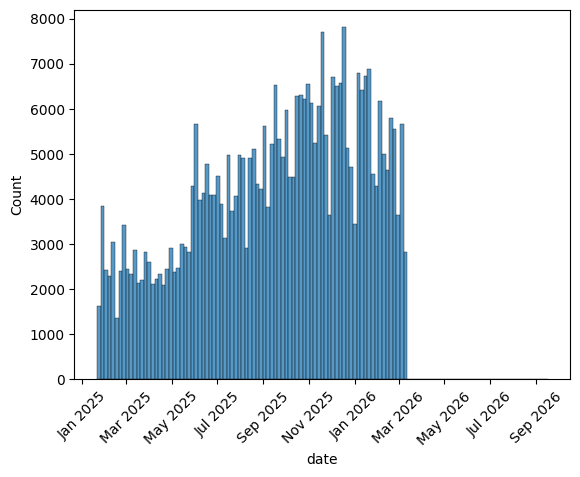

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ax = sns.histplot(x=clean_arrests["date"])
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)


In [11]:
import plotly.express as px

state_abbrev = {
    'ALABAMA': 'AL', 'ALASKA': 'AK', 'ARIZONA': 'AZ', 'ARKANSAS': 'AR', 'CALIFORNIA': 'CA',
    'COLORADO': 'CO', 'CONNECTICUT': 'CT', 'DELAWARE': 'DE', 'FLORIDA': 'FL', 'GEORGIA': 'GA',
    'HAWAII': 'HI', 'IDAHO': 'ID', 'ILLINOIS': 'IL', 'INDIANA': 'IN', 'IOWA': 'IA',
    'KANSAS': 'KS', 'KENTUCKY': 'KY', 'LOUISIANA': 'LA', 'MAINE': 'ME', 'MARYLAND': 'MD',
    'MASSACHUSETTS': 'MA', 'MICHIGAN': 'MI', 'MINNESOTA': 'MN', 'MISSISSIPPI': 'MS',
    'MISSOURI': 'MO', 'MONTANA': 'MT', 'NEBRASKA': 'NE', 'NEVADA': 'NV', 'NEW HAMPSHIRE': 'NH',
    'NEW JERSEY': 'NJ', 'NEW MEXICO': 'NM', 'NEW YORK': 'NY', 'NORTH CAROLINA': 'NC',
    'NORTH DAKOTA': 'ND', 'OHIO': 'OH', 'OKLAHOMA': 'OK', 'OREGON': 'OR', 'PENNSYLVANIA': 'PA',
    'RHODE ISLAND': 'RI', 'SOUTH CAROLINA': 'SC', 'SOUTH DAKOTA': 'SD', 'TENNESSEE': 'TN',
    'TEXAS': 'TX', 'UTAH': 'UT', 'VERMONT': 'VT', 'VIRGINIA': 'VA', 'WASHINGTON': 'WA',
    'WEST VIRGINIA': 'WV', 'WISCONSIN': 'WI', 'WYOMING': 'WY', 'DISTRICT OF COLUMBIA': 'DC'
}

arrests_by_state = clean_arrests.copy()
arrests_by_state["state_code"] = arrests_by_state["state"].map(state_abbrev)
arrests_by_state = arrests_by_state.groupby("state_code").size().reset_index(name="num_arrests")

fig = px.choropleth(arrests_by_state,
                    locations="state_code",
                    locationmode="USA-states",
                    scope="usa",
                    color="num_arrests",
                    color_continuous_scale="Viridis_r",
                    title="ICE Arrests by State (since Jan 20, 2025)",
                    )
fig.show()

In [19]:
arrests_preprocessed = clean_arrests[["date", "state"]].copy()
arrests_preprocessed["state_code"] = arrests_preprocessed["state"].map(state_abbrev)
arrests_preprocessed = arrests_preprocessed.dropna(subset=["state_code"])[["date", "state_code"]]
arrests_preprocessed.to_csv("data/processed/ice_arrests.csv", index=False)
print(f"Saved {len(arrests_preprocessed)} rows to data/processed/ice_arrests.csv")

Saved 372959 rows to data/processed/ice_arrests.csv


## trying to process the county information, will offload to woflram alpha later

In [ ]:
dd = clean_arrests["state"] + ", " + clean_arrests["site"]
dd.to_csv("wo")


318224                 FLORIDA, Collier County 287g Program
318225              GEORGIA, STG GENERAL AREA, NON-SPECIFIC
318229         FLORIDA, ESCAMBIA COUNTY JAIL, PENSACOLA, FL
318231                     VIRGINIA, NORTHERN VIRGINIA AREA
318232    ARIZONA, CAP - MARICOPA COUNTY SHERIFFS OFFICE...
                                ...                        
713459                      NEW JERSEY, PASSAIC COUNTY JAIL
713460                TEXAS, MTG GENERAL AREA, NON-SPECIFIC
713461                      NEW JERSEY, PASSAIC COUNTY JAIL
713462                        NEW JERSEY, ESSEX COUNTY JAIL
713463                    TEXAS, DALLAS COUNTY GENERAL AREA
Length: 374262, dtype: str

In [ ]:
from geopy.geocoders import Photon
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import os

CACHE_PATH = "../data_processing/data/geocode_cache.csv"

geolocator = Photon(user_agent="ice_arrests_geocoder")

# Load cache if it exists
if os.path.exists(CACHE_PATH):
    cache_df = pd.read_csv(CACHE_PATH)
    cache = dict(zip(zip(cache_df["site"], cache_df["state"]), zip(cache_df["lat"], cache_df["lon"])))
else:
    cache = {}

unique_locs = clean_arrests[["site", "state"]].drop_duplicates()
to_geocode = unique_locs[~unique_locs.apply(lambda r: (r["site"], r["state"]) in cache, axis=1)]
print(f"{len(to_geocode)} new locations to geocode")

def geocode_row(row):
    key = (row.site, row.state)
    try:
        result = geolocator.geocode(f"{row.site}, {row.state}, USA", timeout=10)
        return key, (result.latitude, result.longitude) if result else (None, None)
    except Exception:
        return key, (None, None)

rows = list(to_geocode.itertuples(index=False))
with ThreadPoolExecutor(max_workers=50) as executor:
    futures = {executor.submit(geocode_row, row): row for row in rows}
    for future in tqdm(as_completed(futures), total=len(futures)):
        key, coords = future.result()
        cache[key] = coords

# Save updated cache
cache_records = [{"site": k[0], "state": k[1], "lat": v[0], "lon": v[1]} for k, v in cache.items()]
pd.DataFrame(cache_records).to_csv(CACHE_PATH, index=False)

# Merge coords back
cache_df = pd.DataFrame(cache_records)
arrests_geocoded = clean_arrests[["id", "date", "state", "site"]].merge(
    cache_df, on=["site", "state"], how="left"
)
arrests_geocoded

6120 new locations to geocode


In [12]:
from geopy.geocoders import Photon
from concurrent.futures import ThreadPoolExecutor, as_completed

geolocator = Photon(user_agent="ice_arrests_geocoder")

def geocode_row(row):
    key = (row.site, row.state)
    try:
        result = geolocator.geocode(f"{row.site}, {row.state}, USA", timeout=10)
        return key, (result.latitude, result.longitude) if result else (None, None)
    except Exception as e:
        return key, (None, None)

test_rows = list(clean_arrests[["site", "state"]].drop_duplicates().head(10).itertuples(index=False))

with ThreadPoolExecutor(max_workers=5) as executor:
    futures = {executor.submit(geocode_row, row): row for row in test_rows}
    for future in as_completed(futures):
        key, coords = future.result()
        print(key, "->", coords)

('ESCAMBIA COUNTY JAIL, PENSACOLA, FL', 'FLORIDA') -> (None, None)
('NORTHERN VIRGINIA AREA', 'VIRGINIA') -> (None, None)
('CAP - MARICOPA COUNTY SHERIFFS OFFICE JAIL', 'ARIZONA') -> (None, None)
('STG GENERAL AREA, NON-SPECIFIC', 'GEORGIA') -> (None, None)
('Collier County 287g Program', 'FLORIDA') -> (None, None)
('ATLANTA, GA', 'GEORGIA') -> (None, None)
('CHEROKEE COUNTY, GA', 'GEORGIA') -> (None, None)
('WASATCH COUNTY JAIL - UT', 'UTAH') -> (None, None)
('HARRY R. YOUNG CORRECTIONAL INSTITUTION', 'DELAWARE') -> (None, None)
('CITY OF GRAND JUNCTION', 'COLORADO') -> (None, None)
